In [1]:
## -- Check for 3rd party libraries --
try:
    import pytabkit, skrub, shap
    import xgboost as xgb
except:
    %pip install -qq pytabkit skrub shap xgboost==3.1.0
    import pytabkit, skrub, shap
    import xgboost as xgb

Note: you may need to restart the kernel to use updated packages.


In [2]:
## -- Device-Agnostic for GPU --
import torch
print(f"ℹ️ Running on Cuda: {torch.cuda.is_available()}")

# if torch.cuda.is_available():
#     # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
#     # get_ipython().run_line_magic('load_ext', 'cuml.accel')
#     from cuml.preprocessing import TargetEncoder as cuTE
# else:
#     pass

ℹ️ Running on Cuda: True


In [3]:
## -- System dependencies --
import sys, os, gc

## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
from itertools import combinations, product

## -- Machine Learning --
from skrub import TableVectorizer
from pytabkit import (
        RealMLP_TD_Regressor,
        TabM_D_Regressor,
        XGB_TD_Regressor,
        LGBM_TD_Regressor,
        CatBoost_TD_Regressor,
)

import sklearn
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import mean_squared_error, PredictionErrorDisplay

import warnings

print('📚 Libraries imported')

📚 Libraries imported


In [4]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
plt.style.use("ggplot")
# sns.set_style("whitegrid")
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
PALETTE = ['c', 'r', 'orange']

## -- Set Global Seed --
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

COLOR = '\033[32m'
RESET = '\033[0m'

print('⚙️ Functionalities set')
# from google.colab import data_table
# data_table.enable_dataframe_formatter()

⚙️ Functionalities set


In [5]:
# # -- Load Colab Data --
# from google.colab import drive
# drive.mount('/content/drive')

# PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e1 | Student Test Score/student_test_dataset/'
# submit = pd.read_csv(PATH+'sample_submission.csv')
# train = pd.read_csv(PATH+'train.csv').drop('id', axis=1)
# test = pd.read_csv(PATH+'test.csv').drop('id', axis=1)

# TARGET = train.columns[-1]
# NUMS = test.select_dtypes(include='number').columns.tolist()
# CATS = test.select_dtypes(exclude='number').columns.tolist()
# BASE = NUMS + CATS

# orig = pd.read_csv(PATH+'Exam_Score_Prediction.csv').drop('student_id', axis=1)

# for (name, df) in dict(Train=train, Test=test, Original=orig).items():
#     print(f"{name} shape: {df.shape}")

# print(f"\nTotal Numerical: {len(NUMS)}")
# print(f"Total Categorical: {len(CATS)}")
# print(f"Total base features: {len(BASE)}")

In [6]:
## -- Load Data --
PATH = '/kaggle/input/playground-series-s6e1/'
submit = pd.read_csv(PATH+'sample_submission.csv')
train = pd.read_csv(PATH+'train.csv').drop('id', axis=1)
test = pd.read_csv(PATH+'test.csv').drop('id', axis=1)

TARGET = train.columns[-1]
NUMS = test.select_dtypes(include='number').columns.tolist()
CATS = test.select_dtypes(exclude='number').columns.tolist()
BASE = NUMS + CATS

ORIG_PATH = '/kaggle/input/exam-score-prediction-dataset/'
orig = pd.read_csv(ORIG_PATH+'Exam_Score_Prediction.csv').drop('student_id', axis=1)

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (630000, 12)
Test shape: (270000, 11)
Original shape: (20000, 12)

Total Numerical: 4
Total Categorical: 7
Total base features: 11


In [7]:
# ## -- Check if id is unique --
# print(f"Train ID column is Unique: {train.id.is_unique}")
# print(f"Test ID column is Unique: {test.id.is_unique}")

In [8]:
display(train.head())
train.info()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   age               630000 non-null  int64  
 1   gender            630000 non-null  object 
 2   course            630000 non-null  object 
 3   study_hours       630000 non-null  float64
 4   class_attendance  630000 non-null  float64
 5   internet_access   630000 non-null  object 
 6   sleep_hours       630000 non-null  float64
 7   sleep_quality     630000 non-null  object 
 8   study_method      630000 non-null  object 
 9   facility_rating   630000 non-null  object 
 10  exam_difficulty   630000 non-null  object 
 11  exam_score        630000 non-null  float64
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ MB


In [9]:
train.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
age,630000.0,20.545821,2.260238,17.000,19.00,21.0,23.00,24.00
study_hours,630000.0,4.002337,2.359880,0.080,1.97,4.0,6.05,7.91
class_attendance,630000.0,71.987261,17.430098,40.600,57.00,72.6,87.20,99.40
sleep_hours,630000.0,7.072758,1.744811,4.100,5.60,7.1,8.60,9.90
exam_score,630000.0,62.506672,18.916884,19.599,48.80,62.6,76.30,100.00


In [10]:
train.describe(exclude='number').T

,count,unique,top,freq
gender,630000,3,other,211097
course,630000,7,b.tech,131236
internet_access,630000,2,yes,579423
sleep_quality,630000,3,poor,213675
study_method,630000,5,coaching,131697
facility_rating,630000,3,medium,214082
exam_difficulty,630000,3,moderate,353982


In [11]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient(cmap='bone')

,age,study_hours,class_attendance,sleep_hours,gender,course,internet_access,sleep_quality,study_method,facility_rating,exam_difficulty
Train,8,792,617,66,3,7,2,3,5,3,3
Original,8,784,589,59,3,7,2,3,5,3,3
Test,8,786,604,64,3,7,2,3,5,3,3


## FEATURE ENGINEERING

In [12]:
# ## -- Factorize using combined data --
# for c in CATS_2:
#     combine  = pd.concat([train[c], test[c], orig[c]])
#     combine  = combine.factorize()[0]
#     train[c] = combine[:len(train)]
#     test[c]  = combine[len(train):len(train)+len(test)]
#     orig[c]  = combine[-len(orig):]

# ## -- Treat age(8 unique values) as category --
# NUMS.remove('age')
# CATS.append('age')

# print('Label encoding complete!')

In [13]:
# ## -- Create 'meta' feature --
# ## -- https://www.kaggle.com/competitions/playground-series-s6e1/discussion/665915
# def meta_feature(df):
#     formula = (
#         6.0 * df.study_hours + \
#         0.35 * df.class_attendance + \
#         1.5 * df.sleep_hours + \
#         5 * (df.sleep_quality=='good') + \
#         -5 * (df.sleep_quality=='poor') + \
#         10 * (df.study_method=='coaching') + \
#         5 * (df.study_method=='mixed') + \
#         2 * (df.study_method=='group study') + \
#         1 * (df.study_method=='online videos') + \
#         4 * (df.facility_rating=='high') + \
#         -4 * (df.facility_rating=='low')
#     )
#     return formula

# train['formula'] = meta_feature(train)
# test['formula'] = meta_feature(test)
# orig['formula'] = meta_feature(orig)

# ## -- Set ordinal mapping --
# ordinal_maps = {
#     "internet_access": {"no":0, "yes":1},
#     "gender": {"male":0, "female":1, "other":2},
#     "sleep_quality": {"poor":0, "average":1, "good":2},
#     "facility_rating": {"low":0, "medium":1, "high":2},
#     "exam_difficulty": {"easy":0, "moderate":1, "hard":2},
#     "course": {"ba":0, "b.sc":1, "diploma":2, "b.tech":3, "b.com":4, "bca":5, "bba":6},
#     "study_method": {"self-study":0, "online videos":1, "group study":2, "mixed":3, "coaching":4},
# }

# for c in CATS:
#     train[c] = train[c].map(ordinal_maps[c]).fillna(-1)
#     test[c] = test[c].map(ordinal_maps[c]).fillna(-1)
#     orig[c] = orig[c].map(ordinal_maps[c]).fillna(-1)

# print("Feature 'formula' and ordinal label encoded")

In [14]:
def feature_preprocess(df):
    df_temp = df.copy()

    df_temp['study_hours_squared'] = df_temp['study_hours'] ** 2
    df_temp['study_hours_cubed'] = df_temp['study_hours'] ** 3
    df_temp['class_attendance_squared'] = df_temp['class_attendance'] ** 2
    df_temp['sleep_hours_squared'] = df_temp['sleep_hours'] ** 2
    df_temp['age_squared'] = df_temp['age'] ** 2

    # df_temp['log_study_hours'] = np.log1p(df_temp['study_hours'])
    # df_temp['log_class_attendance'] = np.log1p(df_temp['class_attendance'])
    # df_temp['log_sleep_hours'] = np.log1p(df_temp['sleep_hours'])
    # df_temp['sqrt_study_hours'] = np.sqrt(df_temp['study_hours'])
    # df_temp['sqrt_class_attendance'] = np.sqrt(df_temp['class_attendance'])

    # Interaction features
    df_temp['study_hours_times_attendance'] = df_temp['study_hours'] * df_temp['class_attendance']
    df_temp['study_hours_times_sleep'] = df_temp['study_hours'] * df_temp['sleep_hours']
    df_temp['attendance_times_sleep'] = df_temp['class_attendance'] * df_temp['sleep_hours']

    # Ratio features (add small epsilon to avoid division by zero)
    eps = 1e-6
    df_temp['study_hours_over_sleep'] = df_temp['study_hours'] / (df_temp['sleep_hours'] + eps)
    df_temp['attendance_over_sleep'] = df_temp['class_attendance'] / (df_temp['sleep_hours'] + eps)

    # Thanks to Vladimir Demidov for the following feature
    # https://www.kaggle.com/competitions/playground-series-s6e1/discussion/665915
    LUT = {
        'sleep_quality': {'good': 5, 'average': 0, 'poor': -5},
        'facility_rating': {'high': 4, 'medium': 0, 'low': -4},
        'study_method': {
            'coaching': 10,
            'mixed': 5,
            'group study': 2,
            'online videos': 1,
            'self-study': 0
        }
    }

    df_temp['formula'] = 6.0 * df_temp['study_hours'] + 0.35 * df_temp['class_attendance'] \
            + 1.5 * df_temp['sleep_hours'] \
            + df_temp['sleep_quality'].map(LUT['sleep_quality']) \
            + df_temp['study_method'].map(LUT['study_method']) \
            + df_temp['facility_rating'].map(LUT['facility_rating'])

    # Encode categorical variables to numeric ordinal values
    ordinal_maps = {
        "internet_access": {"no":0, "yes":1},
        "gender": {"male":0, "female":1, "other":2},
        "sleep_quality": {"poor":0, "average":1, "good":2},
        "facility_rating": {"low":0, "medium":1, "high":2},
        "exam_difficulty": {"easy":0, "moderate":1, "hard":2},
        "course": {"ba":0, "b.sc":1, "diploma":2, "b.tech":3, "b.com":4, "bca":5, "bba":6},
        "study_method": {"self-study":0, "online videos":1, "group study":2, "mixed":3, "coaching":4},
    }

    for c in CATS:
        df_temp[c] = df_temp[c].map(ordinal_maps[c]).fillna(-1)

    # Interaction between encoded categoricals and key numeric features
    df_temp['study_hours_times_sleep_quality'] = df_temp['study_hours'] * df_temp['sleep_quality']
    df_temp['attendance_times_facility'] = df_temp['class_attendance'] * df_temp['facility_rating']
    df_temp['sleep_hours_times_difficulty'] = df_temp['sleep_hours'] * df_temp['exam_difficulty']
    df_temp['age_times_study_hours'] = df_temp['age'] * df_temp['study_hours']
    df_temp['age_times_attendance'] = df_temp['age'] * df_temp['class_attendance']

    # Composite feature: learning efficiency
    df_temp['efficiency'] = (df_temp['study_hours'] * df_temp['class_attendance']) / (df_temp['sleep_hours'] + 1)
    df_temp["study_efficiency"] = df_temp["study_hours"] * (df_temp["class_attendance"] / 100.0)

    # Cyclic encoding
    for p in [12, 14, 365//2, 365, 365*2, 365*4]:
        df_temp[f"study_hours_sin_{p}"] = np.sin(2 * np.pi * df_temp['study_hours'] / p)
        df_temp[f"class_attendance_sin_{p}"] = np.sin(2 * np.pi * df_temp['class_attendance'] / p)

    total_features = [c for c in df_temp.columns if c != TARGET]
    print(f'Feature Engineered: {len(total_features)}')

    return df_temp

train = feature_preprocess(train)
test = feature_preprocess(test)
orig = feature_preprocess(orig)

Feature Engineered: 41
Feature Engineered: 41
Feature Engineered: 41


In [15]:
## -- Duplicate all features as categories --
CATS_2 = []
for c in BASE:
    n = f"cat_{c}"
    train[n] = train[c].copy()
    test[n] = test[c].copy()
    orig[n] = orig[c].copy()
    CATS_2.append(n)

## -- Factorize using combined data --
    combine  = pd.concat([train[n], test[n], orig[n]])
    v, _ = combine.factorize()
    train[n] = v[:len(train)]
    test[n]  = v[len(train):len(train)+len(test)]
    orig[n]  = v[len(train)+len(test):]

print('CATS_2 - Label encoding complete!')
train.head()

CATS_2 - Label encoding complete!


,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,study_hours_squared,study_hours_cubed,class_attendance_squared,sleep_hours_squared,age_squared,study_hours_times_attendance,study_hours_times_sleep,attendance_times_sleep,study_hours_over_sleep,attendance_over_sleep,formula,study_hours_times_sleep_quality,attendance_times_facility,sleep_hours_times_difficulty,age_times_study_hours,age_times_attendance,efficiency,study_efficiency,study_hours_sin_12,class_attendance_sin_12,study_hours_sin_14,class_attendance_sin_14,study_hours_sin_182,class_attendance_sin_182,study_hours_sin_365,class_attendance_sin_365,study_hours_sin_730,class_attendance_sin_730,study_hours_sin_1460,class_attendance_sin_1460,cat_age,cat_study_hours,cat_class_attendance,cat_sleep_hours,cat_gender,cat_course,cat_internet_access,cat_sleep_quality,cat_study_method,cat_facility_rating,cat_exam_difficulty
0,21,1,1,7.91,98.8,0,4.9,1,1,0,0,78.3,62.5681,494.913671,9761.44,24.01,441,781.508,38.759,484.12,1.614285,20.163261,86.390,7.91,0.0,0.0,166.11,2074.8,132.458983,7.81508,-0.841511,0.994522,-0.397148,0.351375,0.269696,-0.266037,0.135744,0.991566,0.068030,0.751532,0.034035,0.412495,0,0,0,0,0,0,0,0,0,0,0
1,18,2,2,4.95,94.8,1,4.7,0,0,1,1,46.7,24.5025,121.287375,8987.04,22.09,324,469.260,23.265,445.56,1.053191,20.170208,64.930,0.00,94.8,4.7,89.10,1706.4,82.326316,4.69260,0.522499,-0.587785,0.795625,-0.990950,0.170058,-0.130811,0.085107,0.998133,0.042592,0.728379,0.021301,0.396753,1,1,1,1,1,1,1,1,1,1,1
2,20,1,1,4.68,92.6,1,5.8,0,4,2,1,99.0,21.9024,102.503232,8574.76,33.64,400,433.368,27.144,537.08,0.806896,15.965514,78.190,0.00,185.2,5.8,93.60,1852.0,63.730588,4.33368,0.637424,-0.978148,0.863018,-0.657939,0.160866,-0.055209,0.080475,0.999730,0.040270,0.715275,0.020139,0.388044,2,2,2,2,0,0,1,1,2,2,1
3,19,0,1,2.00,49.5,1,8.3,1,2,2,1,63.9,4.0000,8.000000,2450.25,68.89,361,99.000,16.600,410.85,0.240964,5.963855,47.775,2.00,99.0,8.3,38.00,940.5,10.645161,0.99000,0.866025,0.707107,0.781831,-0.222521,0.068991,0.990480,0.034422,0.752667,0.017213,0.413279,0.008607,0.211418,3,3,3,3,2,0,1,0,3,2,1
4,23,0,5,7.65,86.9,1,9.6,2,0,2,0,100.0,58.5225,447.697125,7551.61,92.16,529,664.785,73.440,834.24,0.796875,9.052082,99.715,15.30,173.8,0.0,175.95,1998.7,62.715566,6.64785,-0.760406,0.998630,-0.287599,0.963963,0.261041,0.141072,0.131308,0.997198,0.065797,0.680143,0.032916,0.365322,4,4,4,4,2,2,1,2,1,2,0


In [16]:
TOP_PREDICTORS = ['study_hours', 'class_attendance']
OTHER_PREDICTORS = [c for c in BASE if c not in TOP_PREDICTORS]

print('Feature sets defined!')

Feature sets defined!


In [17]:
## -- Extract Digits --
DIGITS = []

for col in tqdm(TOP_PREDICTORS+['sleep_hours']):
    for d in range(-2, 4):
        n = f'{col}_d{d}'
        train[n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
        test[n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
        orig[n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')

        ## -- Drop constant features --
        if train[n].nunique() < 2:
            train.drop([n], axis=1, inplace=True)
            test.drop([n],  axis=1, inplace=True)
            orig.drop([n],  axis=1, inplace=True)
        else:
            DIGITS.append(n)

print(f'{len(DIGITS)} Feature DIGITS extracted.')
print(train[DIGITS].nunique())

  0%|          | 0/3 [00:00<?, ?it/s]

12 Feature DIGITS extracted.
study_hours_d0           8
study_hours_d1          10
study_hours_d2          10
study_hours_d3           7
class_attendance_d-1     6
class_attendance_d0     10
class_attendance_d1     10
class_attendance_d2     10
class_attendance_d3      3
sleep_hours_d0           6
sleep_hours_d1          10
sleep_hours_d2           5
dtype: int64


In [18]:
# INTER = []

# for c1, c2 in tqdm(list(combinations(TOP_PREDICTORS, 2)), desc='1-to-1 Pairwise'):
#     n_col = f"{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col] = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col] = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(combinations(TOP_PREDICTORS+TOP_PREDICTORS_2, 3)), desc='Triplewise'):
# #     n_col = f"{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col] = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# for c1, c2 in tqdm(list(product(TOP_PREDICTORS, OTHER_PREDICTORS)), desc='1-to-many Pairwise'):
#     n_col2 = f"{c1}-|-{c2}"
#     train[n_col2] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col2] = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col2] = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col2)

# print(f"Interaction Features: {len(INTER)}")

In [19]:
## -- Reduce data memory --
def reduce_memory(data):
    df = data.copy()
    old_size = sys.getsizeof(df) / (1024*1024)
    for c in tqdm(df.columns, desc='Reducing memory...'):
        ## -- Downcast Integer type --
        if df[c].dtype == np.int64:
            if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
                df[c] = df[c].astype(np.int32)
                # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
                #     df[c] = df[c].astype(np.int16)
                #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
                #         df[c] = df[c].astype(np.int8)
        ## -- Downcast Float type --
        # elif df[c].dtype == np.float64:
        #     if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
        #         df[c] = df[c].astype(np.float32)
                # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
                #     df[c] = df[c].astype(np.float16)

    new_size = sys.getsizeof(df) / (1024*1024)
    print(f"Size before process: {old_size:.1f}MB")
    print(f"Size after process : {new_size:.1f}MB\n")

    return df

train = reduce_memory(train)
test  = reduce_memory(test)
orig  = reduce_memory(orig)

gc.collect()

print(f"Dataset size reduced!")

Reducing memory...:   0%|          | 0/65 [00:00<?, ?it/s]

Size before process: 283.6MB
Size after process : 235.5MB



Reducing memory...:   0%|          | 0/64 [00:00<?, ?it/s]

Size before process: 119.5MB
Size after process : 98.9MB



Reducing memory...:   0%|          | 0/65 [00:00<?, ?it/s]

Size before process: 9.0MB
Size after process : 7.5MB

Dataset size reduced!


In [20]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))
train.head(3)

Total Features: 64


,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,study_hours_squared,study_hours_cubed,class_attendance_squared,sleep_hours_squared,age_squared,study_hours_times_attendance,study_hours_times_sleep,attendance_times_sleep,study_hours_over_sleep,attendance_over_sleep,formula,study_hours_times_sleep_quality,attendance_times_facility,sleep_hours_times_difficulty,age_times_study_hours,age_times_attendance,efficiency,study_efficiency,study_hours_sin_12,class_attendance_sin_12,study_hours_sin_14,class_attendance_sin_14,study_hours_sin_182,class_attendance_sin_182,study_hours_sin_365,class_attendance_sin_365,study_hours_sin_730,class_attendance_sin_730,study_hours_sin_1460,class_attendance_sin_1460,cat_age,cat_study_hours,cat_class_attendance,cat_sleep_hours,cat_gender,cat_course,cat_internet_access,cat_sleep_quality,cat_study_method,cat_facility_rating,cat_exam_difficulty,study_hours_d0,study_hours_d1,study_hours_d2,study_hours_d3,class_attendance_d-1,class_attendance_d0,class_attendance_d1,class_attendance_d2,class_attendance_d3,sleep_hours_d0,sleep_hours_d1,sleep_hours_d2
0,21,1,1,7.91,98.8,0,4.9,1,1,0,0,78.3,62.5681,494.913671,9761.44,24.01,441,781.508,38.759,484.12,1.614285,20.163261,86.39,7.91,0.0,0.0,166.11,2074.8,132.458983,7.81508,-0.841511,0.994522,-0.397148,0.351375,0.269696,-0.266037,0.135744,0.991566,0.068030,0.751532,0.034035,0.412495,0,0,0,0,0,0,0,0,0,0,0,7,9,1,0,9,8,8,0,0,4,9,0
1,18,2,2,4.95,94.8,1,4.7,0,0,1,1,46.7,24.5025,121.287375,8987.04,22.09,324,469.260,23.265,445.56,1.053191,20.170208,64.93,0.00,94.8,4.7,89.10,1706.4,82.326316,4.69260,0.522499,-0.587785,0.795625,-0.990950,0.170058,-0.130811,0.085107,0.998133,0.042592,0.728379,0.021301,0.396753,1,1,1,1,1,1,1,1,1,1,1,4,9,5,0,9,4,8,0,0,4,7,0
2,20,1,1,4.68,92.6,1,5.8,0,4,2,1,99.0,21.9024,102.503232,8574.76,33.64,400,433.368,27.144,537.08,0.806896,15.965514,78.19,0.00,185.2,5.8,93.60,1852.0,63.730588,4.33368,0.637424,-0.978148,0.863018,-0.657939,0.160866,-0.055209,0.080475,0.999730,0.040270,0.715275,0.020139,0.388044,2,2,2,2,0,0,1,1,2,2,1,4,6,8,0,9,2,6,0,0,5,8,0


In [21]:
from sklearn.base import BaseEstimator, TransformerMixin

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

In [22]:
assert set(train[FEATURES].columns.tolist()) == set(orig[FEATURES].columns.tolist()), 'Not same features'

# ML TRAINING


##### FOLD 1/8
####################
-> Model_1 -> tabM3 RMSE: 8.57093
[0]	train-rmse:18.01756	valid-rmse:18.78020
[500]	train-rmse:6.99758	valid-rmse:8.81134
[1000]	train-rmse:6.65641	valid-rmse:8.59510
[1500]	train-rmse:6.58533	valid-rmse:8.57791
[2000]	train-rmse:6.53621	valid-rmse:8.57294
[2500]	train-rmse:6.48957	valid-rmse:8.57008
[3000]	train-rmse:6.44471	valid-rmse:8.56791
[3500]	train-rmse:6.40096	valid-rmse:8.56618
[4000]	train-rmse:6.35973	valid-rmse:8.56509
[4500]	train-rmse:6.32048	valid-rmse:8.56425
[5000]	train-rmse:6.28075	valid-rmse:8.56341
[5500]	train-rmse:6.24232	valid-rmse:8.56297
[6000]	train-rmse:6.20554	valid-rmse:8.56260
[6500]	train-rmse:6.16815	valid-rmse:8.56253
[6771]	train-rmse:6.14856	valid-rmse:8.56260
-> Model_2 RMSE: 8.56248

##### FOLD 2/8
####################
-> Model_1 -> tabM3 RMSE: 8.62522
[0]	train-rmse:18.14749	valid-rmse:18.77364
[500]	train-rmse:6.99605	valid-rmse:8.84675
[1000]	train-rmse:6.65073	valid-rmse:8.64716
[1500]	train-rmse:6.57905	v

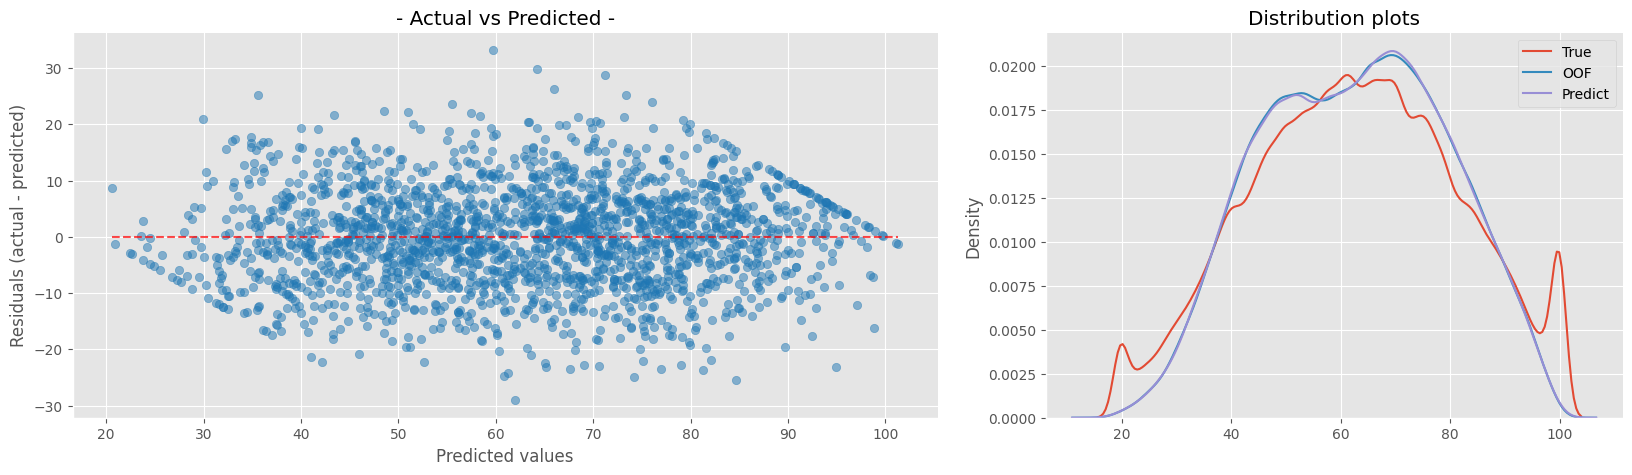

Training Time: 113.20 mins =========================


In [23]:
## -- DEFINE TRAINING PARAMETERS --
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

## -- Split data --
X = train[FEATURES]
X_orig = orig[FEATURES]

y = train[TARGET].values
y_orig = orig[TARGET].values

kf = KFold(n_splits=8, shuffle=True, random_state=SEED)

oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(test))
fold_scores = []

params = {
    # 'grow_policy': 'depthwise', #'lossguide',
    'objective': 'reg:squarederror',
    'eval_metric': "rmse",
    'learning_rate': 0.005,
    'max_depth': 8,
    'subsample': 0.85,
    'colsample_bytree': 0.35,
    'reg_lambda': 3.0,
    'reg_alpha': 1.5,
    'min_child_weight': 10,
    'random_state': SEED,
    'verbosity': 0,
    'n_jobs': os.cpu_count(),
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

## -- Initiate Training --
tik = time()
for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\n{'#'*5} FOLD {fold+1}/{kf.n_splits}")
    print(f"{'#'*20}")

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    X_test = test[FEATURES].copy()

    ## -- Concatenate original data when not using base_score --
    X_train = pd.concat([X_train, X_orig], ignore_index=True)
    y_train = np.concatenate([y_train, y_orig], axis=0)

    # ## -- TE Opt1. -> Using CUSTOM
    # TE = TargetEncoder(INTER, cv=4, smooth='auto', aggs=['mean'], drop_original=True)
    # X_train = TE.fit_transform(X_train, pd.Series(y_train))
    # X_val   = TE.transform(X_val)
    # X_test  = TE.transform(X_test)

    # ## -- TE Opt2. -- Using RAPIDS
    # for c in CATS_2[1:3]:
    #     TE = cuTE(n_folds=4, smooth=0, stat='mean', split_method='random', seed=SEED)
    #     # n = f"TE_{c}"
    #     X_train[c] = TE.fit_transform(X_train[c], y_train)
    #     X_val[c]   = TE.transform(X_val[c])
    #     X_test[c]  = TE.transform(X_test[c])

    ## -- PyTabKit: Train Stage 1 model --
    model_1 = TabM_D_Regressor(random_state=SEED)
    # model_1 = RealMLP_TD_Regressor(random_state=SEED)
    m = 'tabM3'

    model_1.fit(X_train, y_train, X_val, y_val, cat_col_names=CATS_2+DIGITS) 
    oof_m1 = model_1.predict(X_val)
    test_m1 = model_1.predict(X_test)

    print(f"-> Model_1 -> {m} RMSE: {rmse(y_val, oof_m1):.5f}")

    ## -- PSEUDO LABELS FROM model_1 AS FEATURES FOR model_2 --
    X_train_full = pd.concat([X_train, X_val, X_test], ignore_index=True).copy()
    y_train_full = np.concatenate([y_train, oof_m1, test_m1], axis=0)

    for c in CATS_2 + DIGITS:
        X_train_full[c] = X_train_full[c].astype('category')

    X_val_2  = X_train_full.iloc[len(X_train):len(X_train)+len(X_val)]
    X_test_2 = X_train_full.iloc[len(X_train)+len(X_val):]

    dtrain = xgb.DMatrix(X_train_full, y_train_full, enable_categorical=True)
    dval   = xgb.DMatrix(X_val_2, y_val, enable_categorical=True)
    dtest  = xgb.DMatrix(X_test_2, enable_categorical=True)

    model_2 = xgb.train(
        params,
        dtrain,
        num_boost_round = 10_000,
        evals = [(dtrain, "train"), (dval, "valid")],
        early_stopping_rounds = 250,
        verbose_eval = 500,
    )

    y_pred = model_2.predict(dval, iteration_range=(0, model_2.best_iteration + 1))
    oof_preds[val_idx] = y_pred
    fold_scores.append(rmse(y_val, y_pred))

    predictions = model_2.predict(dtest, iteration_range=(0, model_2.best_iteration + 1))
    test_preds += predictions / kf.n_splits

    print(f"-> Model_2 RMSE: {rmse(y_val, y_pred):.5f}")

    gc.collect()
    torch.cuda.empty_cache()

## -- After all folds --
overall_score = np.round(rmse(y, oof_preds), 5)
print(f"|{'-'*50}{COLOR}")
print(f"|  DATASET: {X_train_full.shape}")
print(f"| OOF RMSE: {overall_score}")
print(f"| AVG RMSE: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}{RESET}")

## -- Plot predictions errors --
_, axs = plt.subplots(1, 2, figsize=(20, 5), gridspec_kw={'width_ratios':[0.6, 0.4], 'wspace':0.15})
display = PredictionErrorDisplay.from_predictions(
    y,
    oof_preds,
    ax=axs[0],
    subsample=2000,
    # kind = "actual_vs_predicted",
    scatter_kwargs={"alpha": 0.5}, line_kwargs={'color': 'r'},
)
axs[0].set_title(f"- Actual vs Predicted -")

LABELS = ['True', 'OOF', 'Predict']
sns.kdeplot(y, ax=axs[1], label=LABELS[0])
sns.kdeplot(oof_preds, ax=axs[1], label=LABELS[1])
sns.kdeplot(test_preds, ax=axs[1], label=LABELS[2])
axs[1].set_title(f"Distribution plots")

for ax in axs:
    # ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.legend()
plt.tight_layout()
plt.show()

tok = time()
tiktok = (tok-tik) / 60
print(f"Training Time: {tiktok:.2f} mins {'='*25}")

In [24]:
float(overall_score)

8.59842

In [25]:
# 0.01 | 5folds | No INTER (TE)
# DATASET: 35
# OOF RMSE: 8.60329
# AVG RMSE: 8.60328 ± 0.00929

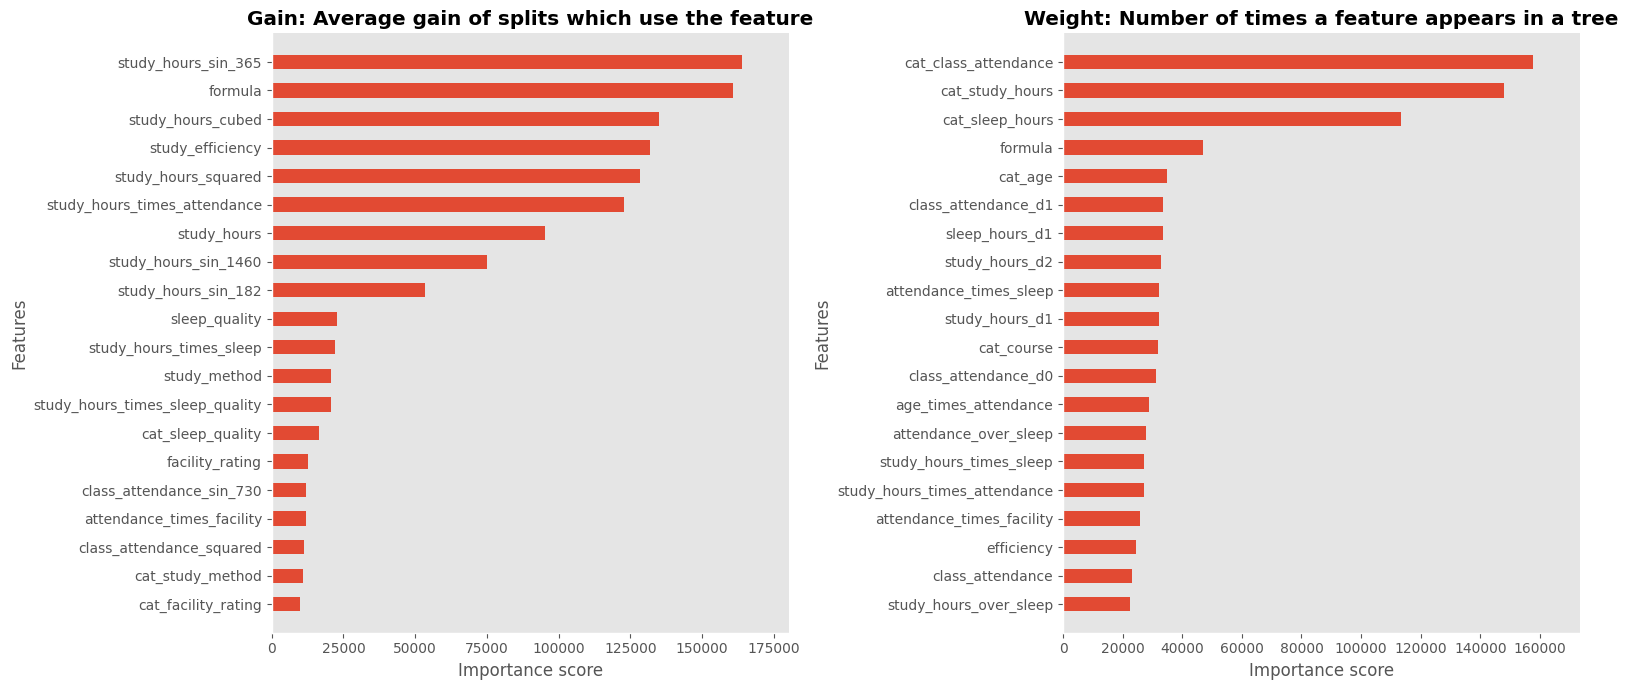

In [26]:
## -- Plot Feature Importances --
MAX = 20
_, axs = plt.subplots(1, 2, figsize=(16, 7))
xgb.plot_importance(
                    model_2, ax=axs[0],
                    max_num_features=MAX,
                    importance_type='gain',
                    height=0.5, show_values=False, grid=False,
    )
axs[0].set_title('Gain: Average gain of splits which use the feature', fontdict={'weight': 'bold'})

xgb.plot_importance(
                    model_2, ax=axs[1],
                    max_num_features=MAX,
                    importance_type='weight',
                    height=0.5, show_values=False, grid=False,
    )
axs[1].set_title('Weight: Number of times a feature appears in a tree', fontdict={'weight': 'bold'})

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## SUBMISSION

In [27]:
name = f"xgb_{m}_pseudo_" + f"{overall_score}".split('.')[1]
oof_final = pd.DataFrame(oof_preds, columns=[name])
test_final = pd.DataFrame(test_preds, columns=[name])

oof_final.shape, test_final.shape

((630000, 1), (270000, 1))

In [28]:
## -- Save OOF & PREDICTIONS --
oof_final.to_parquet(f"oof_{name}.parquet", index=False)
test_final.to_parquet(f"pred_{name}.parquet", index=False)

## -- Submission file --
submit[TARGET] = np.clip(test_final.values, min(y), max(y))
submit.to_csv(f"submit_{name}.csv", index=False)
submit.head()

,id,exam_score
0,630000,68.382638
1,630001,68.441369
2,630002,90.670236
3,630003,56.646885
4,630004,46.941861
